### Classification

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy ", accuracy_score(y_test, y_pred))
print(f"classification_report ", classification_report(y_test, y_pred))

k=1, Accuracy=1.0
k=2, Accuracy=1.0
k=3, Accuracy=1.0
k=4, Accuracy=1.0
k=5, Accuracy=1.0
k=6, Accuracy=1.0
k=7, Accuracy=1.0
k=8, Accuracy=1.0
k=9, Accuracy=1.0
k=10, Accuracy=1.0


## CV Score

In [19]:
from sklearn.model_selection import cross_val_score

for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)
    
    print(f"k={k}, Mean Accuracy={scores.mean()}")

k=1, Mean Accuracy=0.96
k=2, Mean Accuracy=0.9466666666666665
k=3, Mean Accuracy=0.9666666666666668
k=4, Mean Accuracy=0.9733333333333334
k=5, Mean Accuracy=0.9733333333333334
k=6, Mean Accuracy=0.9800000000000001
k=7, Mean Accuracy=0.9800000000000001
k=8, Mean Accuracy=0.9666666666666668
k=9, Mean Accuracy=0.9733333333333334
k=10, Mean Accuracy=0.9800000000000001


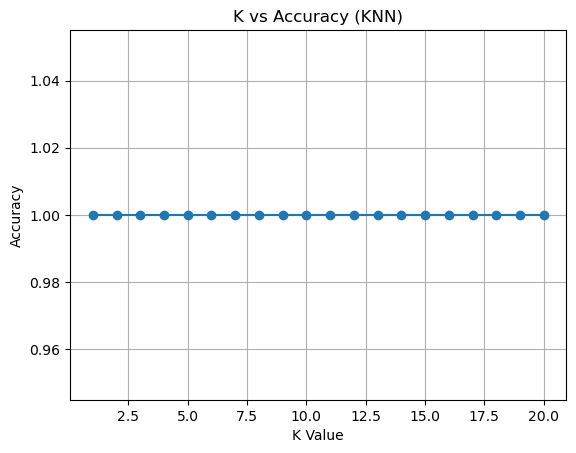

In [21]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = []
accuracies = []

for k in range(1, 21):  # k from 1 to 20
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    k_values.append(k)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (KNN)")
plt.grid()
plt.show()

### Regression for KNN without Feature Scaling

In [12]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error,r2_score

data = fetch_california_housing()
X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = KNeighborsRegressor(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("r2_score:", r2_score(y_test, y_pred))

MSE: 0.45562317913777184
r2_score: 0.6594906905584005


### Regression for KNN without Feature Scaling

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsRegressor(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("r2_score:", r2_score(y_test, y_pred))

MSE: 0.007407407407407405
r2_score: 0.9882835383714118


In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = []
mse_values = []

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    k_values.append(k)
    mse_values.append(mean_squared_error(y_test, y_pred))


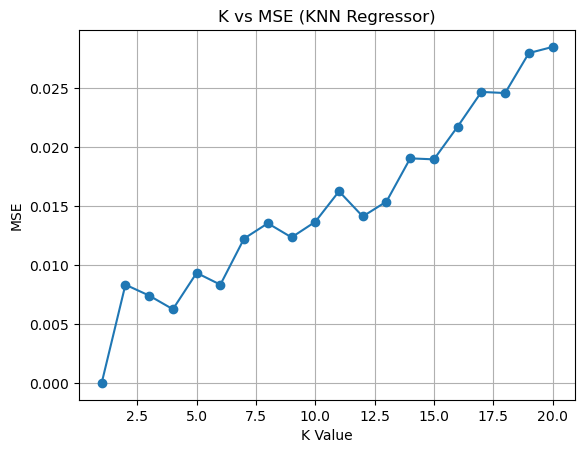

In [23]:
import matplotlib.pyplot as plt

plt.plot(k_values, mse_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("MSE")
plt.title("K vs MSE (KNN Regressor)")
plt.grid()
plt.show()